In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from datetime import datetime
from scipy.stats import spearmanr

In [2]:
# Load all parquet files from polarity/data/ into a single DataFrame
df = (
    pl.read_parquet('polarity/data/*.parquet')
        .rename({'asset': 'symbol'})
)

In [3]:
# Convert price to log returns and calculate n-day target returns
n = 7
df = df.sort(['symbol', 'timestamp'])
df = df.with_columns([
    pl.col('price').log().diff().over('symbol').alias('log_return')
])
df = df.with_columns([
    pl.col('log_return').rolling_sum(window_size=n).shift(-n).over('symbol').alias('target')
])

In [4]:
# Derive new features tcid and mdcd
df = df.with_columns([
    ((pl.col('tcicv') - pl.col('price')) / pl.col('price')).alias('tcid'),
    ((pl.col('mdccv') - pl.col('price')) / pl.col('price')).alias('mdcd')
])
z_window = 30
def rolling_zscore(column, window):
    return (pl.col(column) - pl.col(column).rolling_mean(window)) / pl.col(column).rolling_std(window)

df = df.with_columns([
    rolling_zscore('tcid', z_window).over('symbol').alias('tcid_z'),
    rolling_zscore('mdcd', z_window).over('symbol').alias('mdcd_z'),
    rolling_zscore('upprob', z_window).over('symbol').alias('upprob_z')
])
df = df.drop_nulls(subset=['tcid_z', 'mdcd_z', 'upprob_z'])

In [5]:
def compute_metrics(returns, benchmark_rets=None):
    if len(returns) == 0:
        return {"Return": 0, "Sharpe": 0, "MaxDD": 0, "IR": 0}
    ann_return = returns.mean() * 365
    ann_std = returns.std() * np.sqrt(365)
    sharpe = ann_return / ann_std if ann_std != 0 else 0
    cum_returns = returns.cum_sum().exp()
    rolling_max = cum_returns.cum_max()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()
    ir = 0
    if benchmark_rets is not None:
        active_return = returns - benchmark_rets
        active_ann_return = active_return.mean() * 365
        tracking_error = active_return.std() * np.sqrt(365)
        ir = active_ann_return / tracking_error if tracking_error != 0 else 0
    return {"Return": ann_return, "Sharpe": sharpe, "MaxDD": max_dd, "IR": ir}

features = ['upprob_z', 'mdcd_z', 'tcid_z', 'mbi', 'udpil', 'udpis', 'udpim', 'tci']
horizons = {'1w': 7, '1m': 30, '2m': 60, '3m': 90}
btc_returns = df.filter(pl.col('symbol') == 'btc').select(['timestamp', 'log_return']).rename({'log_return': 'btc_return'})

In [6]:
# Basic Comparison: Linear vs GBT
all_metrics = []
for label, days in horizons.items():
    print(f"Backtesting {label} horizon with per-coin models (Linear & GBT)...")
    work_df = df.with_columns([
        pl.col('log_return').rolling_sum(window_size=days).shift(-days).over('symbol').alias('fwd_ret')
    ]).drop_nulls(subset=['fwd_ret'] + features)
    preds_lin, preds_gbt = [], []
    symbols = work_df['symbol'].unique().to_list()
    for sym in symbols:
        sym_df = work_df.filter(pl.col('symbol') == sym)
        train_sym = sym_df.filter(pl.col('timestamp') < datetime(2024, 1, 1))
        if train_sym.height < 100: continue
        X_train, y_train, X_all = train_sym[features].to_pandas(), train_sym['fwd_ret'].to_pandas(), sym_df[features].to_pandas()
        model_lin = LinearRegression().fit(X_train, y_train)
        model_gbt = HistGradientBoostingRegressor(max_iter=50, max_depth=3, random_state=42).fit(X_train, y_train)
        base_cols = sym_df.select(['symbol', 'timestamp', 'log_return', 'fwd_ret'])
        preds_lin.append(base_cols.with_columns(pl.Series(name='pred', values=model_lin.predict(X_all))))
        preds_gbt.append(base_cols.with_columns(pl.Series(name='pred', values=model_gbt.predict(X_all))))
    if not preds_lin: continue
    for model_name, preds_list in [('Linear', preds_lin), ('GBT', preds_gbt)]:
        combined_preds = pl.concat(preds_list)
        combined_preds = combined_preds.with_columns(pl.col('pred').rank(descending=False).over('timestamp').alias('pred_rank_val'))
        combined_preds = combined_preds.with_columns((pl.col('pred_rank_val') / pl.col('pred_rank_val').max().over('timestamp')).alias('final_rank'))
        portfolio_rets = combined_preds.group_by('timestamp').agg([
            pl.col('log_return').filter((pl.col('final_rank') >= 0.9) & (pl.col('pred') > 0)).mean().alias('long_ret'),
            pl.col('log_return').filter((pl.col('final_rank') <= 0.1) & (pl.col('pred') < 0)).mean().alias('short_ret')
        ]).with_columns([pl.col('long_ret').fill_null(0), pl.col('short_ret').fill_null(0)]).with_columns((pl.col('long_ret') - pl.col('short_ret')).alias('port_ret')).join(btc_returns, on='timestamp').sort('timestamp')
        portfolio_rets = portfolio_rets.with_columns(pl.col('timestamp').dt.year().alias('year'))
        for year, year_df in portfolio_rets.group_by('year'):
            y_val = year[0] if isinstance(year, tuple) else year
            p_metrics = compute_metrics(year_df['port_ret'], year_df['btc_return'])
            year_preds = combined_preds.filter(pl.col('timestamp').dt.year() == y_val)
            ic = spearmanr(year_preds['pred'], year_preds['fwd_ret'])[0] if year_preds.height > 10 else np.nan
            all_metrics.append({'Horizon': label, 'Model': model_name, 'Year': y_val, 'Return': p_metrics['Return'], 'IR': p_metrics['IR'], 'IC': ic, 'MaxDD': p_metrics['MaxDD']})

results_df = pd.DataFrame(all_metrics)

Backtesting 1w horizon with per-coin models (Linear & GBT)...
Backtesting 1m horizon with per-coin models (Linear & GBT)...
Backtesting 2m horizon with per-coin models (Linear & GBT)...
Backtesting 3m horizon with per-coin models (Linear & GBT)...


In [7]:
# Walk-Forward (Monthly)
horizon_days = 30
rebalance_freq = 'MS'
wf_df = df.with_columns([pl.col('log_return').rolling_sum(window_size=horizon_days).shift(-horizon_days).over('symbol').alias('fwd_ret_30')]).sort('timestamp')
all_dates = wf_df['timestamp'].unique().sort()
rebalance_dates = pd.date_range(start=all_dates.min(), end=all_dates.max(), freq=rebalance_freq)
daily_records = []
for i in range(len(rebalance_dates) - 1):
    t_start, t_end = rebalance_dates[i], rebalance_dates[i+1]
    train_data = wf_df.filter(pl.col('timestamp') < t_start).drop_nulls(subset=['fwd_ret_30'] + features)
    symbols_to_predict = wf_df.filter(pl.col('timestamp') == t_start)['symbol'].unique().to_list()
    if train_data.height < 500 or len(symbols_to_predict) < 10: continue
    preds = []
    for sym in symbols_to_predict:
        sym_train = train_data.filter(pl.col('symbol') == sym)
        if sym_train.height < 50: continue
        model = LinearRegression().fit(sym_train[features].to_pandas(), sym_train['fwd_ret_30'].to_pandas())
        current_features = wf_df.filter((pl.col('timestamp') == t_start) & (pl.col('symbol') == sym))[features]
        if current_features.height == 0: continue
        preds.append({'symbol': sym, 'pred': model.predict(current_features.to_pandas())[0]})
    if not preds: continue
    pdf = pd.DataFrame(preds); pdf['rank'] = pdf['pred'].rank(pct=True)
    longs, shorts = pdf[(pdf['rank'] >= 0.9) & (pdf['pred'] > 0)]['symbol'].tolist(), pdf[(pdf['rank'] <= 0.1) & (pdf['pred'] < 0)]['symbol'].tolist()
    period_days = wf_df.filter((pl.col('timestamp') >= t_start) & (pl.col('timestamp') < t_end))
    for d in period_days['timestamp'].unique().sort():
        day_data = period_days.filter(pl.col('timestamp') == d)
        l_ret = day_data.filter(pl.col('symbol').is_in(longs))['log_return'].mean() if longs else 0
        s_ret = day_data.filter(pl.col('symbol').is_in(shorts))['log_return'].mean() if shorts else 0
        l_ret, s_ret = (l_ret if l_ret is not None else 0), (s_ret if s_ret is not None else 0)
        
        # Apply 0.2% entry + 0.2% exit fee (0.4% total) on rebalance day
        p_ret = l_ret - s_ret
        if d == t_start:
            p_ret += np.log(1 - 0.004)
            
        daily_records.append({'timestamp': d, 'port_ret': p_ret})
results_wf = pd.DataFrame(daily_records).set_index('timestamp')

Starting Staggered Weekly Walk-Forward...


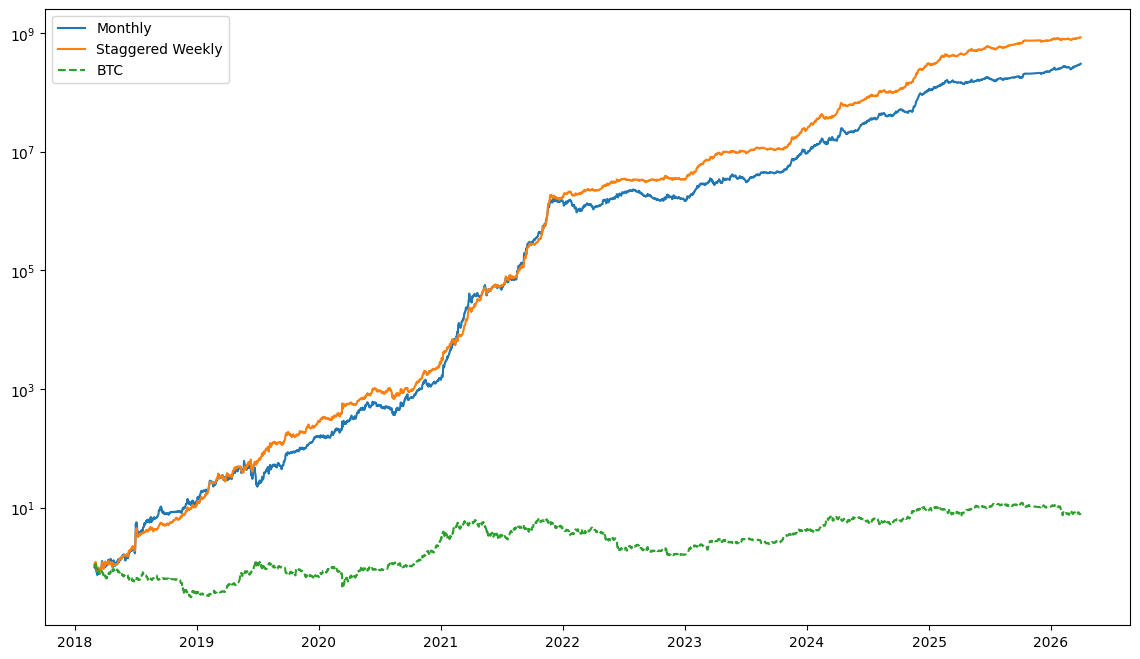


Staggered Weekly Metrics:
{'Return': 2.567353990982937, 'Sharpe': np.float64(3.5350663499136634), 'MaxDD': -0.3777003424940336, 'IR': np.float64(2.2384457500210084)}

Monthly Metrics:
{'Return': 2.4389747798761783, 'Sharpe': np.float64(2.628871199238382), 'MaxDD': -0.6324461084998869, 'IR': np.float64(1.872207598000684)}


In [8]:
# Walk-Forward (Staggered Weekly)
n_tranches = 4
fridays = wf_df.select(pl.col('timestamp').unique().sort()).filter(pl.col('timestamp').dt.weekday() == 5)['timestamp'].to_list()
tranches, daily_records_staggered = [None] * n_tranches, []
print("Starting Staggered Weekly Walk-Forward...")
for d in all_dates:
    if d in fridays:
        week_idx = fridays.index(d)
        tranche_idx = week_idx % n_tranches
        train_data = wf_df.filter(pl.col('timestamp') < d).drop_nulls(subset=['fwd_ret_30'] + features)
        symbols_to_predict = wf_df.filter(pl.col('timestamp') == d)['symbol'].unique().to_list()
        if train_data.height > 500 and len(symbols_to_predict) >= 10:
            preds = []
            for sym in symbols_to_predict:
                sym_train = train_data.filter(pl.col('symbol') == sym)
                if sym_train.height < 50: continue
                model = LinearRegression().fit(sym_train[features].to_pandas(), sym_train['fwd_ret_30'].to_pandas())
                current_features = wf_df.filter((pl.col('timestamp') == d) & (pl.col('symbol') == sym))[features]
                if current_features.height == 0: continue
                preds.append({'symbol': sym, 'pred': model.predict(current_features.to_pandas())[0]})
            if preds:
                pdf = pd.DataFrame(preds); pdf['rank'] = pdf['pred'].rank(pct=True)
                tranches[tranche_idx] = {'longs': pdf[(pdf['rank'] >= 0.9) & (pdf['pred'] > 0)]['symbol'].tolist(), 'shorts': pdf[(pdf['rank'] <= 0.1) & (pdf['pred'] < 0)]['symbol'].tolist()}
    tranche_rets = []
    day_data = wf_df.filter(pl.col('timestamp') == d)
    for t in tranches:
        if t is not None:
            l_ret = day_data.filter(pl.col('symbol').is_in(t['longs']))['log_return'].mean() if t['longs'] else 0
            s_ret = day_data.filter(pl.col('symbol').is_in(t['shorts']))['log_return'].mean() if t['shorts'] else 0
            tranche_rets.append((l_ret if l_ret is not None else 0) - (s_ret if s_ret is not None else 0))
    if tranche_rets: 
        avg_port_ret = sum(tranche_rets) / n_tranches
        # Apply 0.2% entry + 0.2% exit fee (0.4% total) on 1/4 of the portfolio
        if d in fridays:
            avg_port_ret += np.log(1 - 0.004 * (1/n_tranches))
        daily_records_staggered.append({'timestamp': d, 'port_ret': avg_port_ret})

results_staggered = pd.DataFrame(daily_records_staggered).set_index('timestamp')
btc_daily = btc_returns.to_pandas().set_index('timestamp')
comparison = results_staggered[['port_ret']].join(results_wf[['port_ret']], how='inner', rsuffix='_monthly').join(btc_daily, how='left')
comparison['cum_staggered'] = comparison['port_ret'].cumsum().apply(np.exp)
comparison['cum_monthly'] = comparison['port_ret_monthly'].cumsum().apply(np.exp)
comparison['cum_btc'] = comparison['btc_return'].cumsum().apply(np.exp)

plt.figure(figsize=(14, 8)); plt.plot(comparison.index, comparison['cum_monthly'], label='Monthly'); plt.plot(comparison.index, comparison['cum_staggered'], label='Staggered Weekly'); plt.plot(comparison.index, comparison['cum_btc'], label='BTC', linestyle='--'); plt.yscale('log'); plt.legend(); plt.show()
print("\nStaggered Weekly Metrics:"); print(compute_metrics(pl.from_pandas(comparison.reset_index())['port_ret'], pl.from_pandas(comparison.reset_index())['btc_return']))
print("\nMonthly Metrics:"); print(compute_metrics(pl.from_pandas(comparison.reset_index())['port_ret_monthly'], pl.from_pandas(comparison.reset_index())['btc_return']))

In [9]:
# Trade-level Analysis: Staggered Weekly Strategy (Linear 1m)
# Tracking individual trades: entry, path (min/max), exit, fees, and returns.

trade_records = []
tranches_trades_store = [None] * n_tranches

print("Starting Trade-level Analysis for Staggered Weekly Strategy (Linear)...")

for d in all_dates:
    # 1. Rebalance logic: Is today a Friday?
    if d in fridays:
        week_idx = fridays.index(d)
        tranche_idx = week_idx % n_tranches
        
        # Close existing trades in this tranche
        if tranches_trades_store[tranche_idx] is not None:
            old_trades = tranches_trades_store[tranche_idx]
            exit_date = d
            exit_prices = wf_df.filter(pl.col('timestamp') == exit_date).select(['symbol', 'price'])
            exit_price_dict = dict(zip(exit_prices['symbol'], exit_prices['price']))
            
            for trade in old_trades:
                e_price = exit_price_dict.get(trade['symbol'])
                if e_price is not None:
                    trade['exit_price'] = e_price
                    trade['exit_date'] = exit_date
                    trade['log_ret'] = np.log(trade['exit_price'] / trade['entry_price']) * trade['side'] + np.log(1 - 0.004)
                    trade_records.append(trade)

        # Open new trades for this tranche
        train_data_t = wf_df.filter(pl.col('timestamp') < d).drop_nulls(subset=['fwd_ret_30'] + features)
        symbols_to_predict = wf_df.filter(pl.col('timestamp') == d)['symbol'].unique().to_list()
        
        new_tranche_trades = []
        if train_data_t.height > 500 and len(symbols_to_predict) >= 10:
            preds_list = []
            for sym in symbols_to_predict:
                sym_train = train_data_t.filter(pl.col('symbol') == sym)
                if sym_train.height < 50: continue
                model = LinearRegression().fit(sym_train[features].to_pandas(), sym_train['fwd_ret_30'].to_pandas())
                current_row = wf_df.filter((pl.col('timestamp') == d) & (pl.col('symbol') == sym))
                if current_row.height == 0: continue
                preds_list.append({'symbol': sym, 'pred': model.predict(current_row[features].to_pandas())[0], 'price': current_row['price'][0]})
            
            if preds_list:
                pdf_preds = pd.DataFrame(preds_list)
                pdf_preds['rank'] = pdf_preds['pred'].rank(pct=True)
                
                # Longs
                for _, row in pdf_preds[(pdf_preds['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
                    new_tranche_trades.append({
                        'symbol': row['symbol'], 'entry_date': d, 'entry_price': row['price'],
                        'side': 1, 'high_price': row['price'], 'low_price': row['price']
                    })
                # Shorts
                for _, row in pdf_preds[(pdf_preds['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
                    new_tranche_trades.append({
                        'symbol': row['symbol'], 'entry_date': d, 'entry_price': row['price'],
                        'side': -1, 'high_price': row['price'], 'low_price': row['price']
                    })
        tranches_trades_store[tranche_idx] = new_tranche_trades

    # 2. Daily path tracking (High/Low)
    day_prices = wf_df.filter(pl.col('timestamp') == d).select(['symbol', 'price'])
    price_dict_path = dict(zip(day_prices['symbol'], day_prices['price']))
    
    for t_list in tranches_trades_store:
        if t_list:
            for trade in t_list:
                curr_price = price_dict_path.get(trade['symbol'])
                if curr_price is not None:
                    trade['high_price'] = max(trade['high_price'], curr_price)
                    trade['low_price'] = min(trade['low_price'], curr_price)

# Process completed trades
trades_df = pd.DataFrame(trade_records)
trades_df['mfe'] = np.where(trades_df['side'] == 1, (trades_df['high_price'] / trades_df['entry_price']) - 1, (trades_df['entry_price'] / trades_df['low_price']) - 1)
trades_df['mae'] = np.where(trades_df['side'] == 1, (trades_df['low_price'] / trades_df['entry_price']) - 1, (trades_df['entry_price'] / trades_df['high_price']) - 1)
trades_df['win'] = trades_df['log_ret'] > 0

# Stats
print("\nLinear Trade Statistics (N_total=%d):" % len(trades_df))
for group in ['All', 'Winners', 'Losers']:
    df_grp = trades_df if group == 'All' else trades_df[trades_df['win'] == (group == 'Winners')]
    print(f"\n--- {group} (N={len(df_grp)}) ---")
    if len(df_grp) > 0:
        summary = df_grp[['mfe', 'mae', 'log_ret']].agg(['mean', 'std'])
        print(summary)
        print(f"Mean Log Return: {summary.loc['mean', 'log_ret']:.4f}, Std: {summary.loc['std', 'log_ret']:.4f}")
        print(f"Mean MFE: {summary.loc['mean', 'mfe']:.4f}, Std: {summary.loc['std', 'mfe']:.4f}")
        print(f"Mean MAE: {summary.loc['mean', 'mae']:.4f}, Std: {summary.loc['std', 'mae']:.4f}")

# Kelly Criterion
mean_ret = trades_df['log_ret'].mean(); var_ret = trades_df['log_ret'].var()
full_kelly = mean_ret / var_ret if var_ret > 0 else 0
print(f"\nWin Probability: {trades_df['win'].mean():.2%}")
print(f"Expected Log Return per Trade: {mean_ret:.4f}")
print(f"Optimal Bet Size (Full Kelly): {full_kelly:.4f}")
print(f"Optimal Bet Size (Half Kelly): {full_kelly/2:.4f}")

Starting Trade-level Analysis for Staggered Weekly Strategy...

Trade Statistics (N_total=2827):

--- All (N=2827) ---
           mfe       mae   log_ret
mean  0.378083 -0.136196  0.088941
std   0.636630  0.129979  0.370662
Mean Log Return: 0.0889, Std: 0.3707
Mean MFE: 0.3781, Std: 0.6366
Mean MAE: -0.1362, Std: 0.1300

--- Winners (N=1641) ---
           mfe       mae   log_ret
mean  0.586786 -0.066083  0.309372
std   0.765463  0.069326  0.308464
Mean Log Return: 0.3094, Std: 0.3085
Mean MFE: 0.5868, Std: 0.7655
Mean MAE: -0.0661, Std: 0.0693

--- Losers (N=1186) ---
           mfe       mae   log_ret
mean  0.089314 -0.233206 -0.216057
std   0.108948  0.131956  0.188617
Mean Log Return: -0.2161, Std: 0.1886
Mean MFE: 0.0893, Std: 0.1089
Mean MAE: -0.2332, Std: 0.1320

Win Probability: 58.05%
Expected Log Return per Trade: 0.0889


In [10]:
# Trade-level Analysis: Staggered Weekly Strategy (XGBoost GBT)
trade_records_xgb = []
tranches_trades_xgb = [None] * n_tranches
print("\nStarting Trade-level Analysis for Staggered Weekly Strategy (XGBoost)...")

for d in all_dates:
    if d in fridays:
        week_idx = fridays.index(d); tranche_idx = week_idx % n_tranches
        if tranches_trades_xgb[tranche_idx] is not None:
            old_trades = tranches_trades_xgb[tranche_idx]
            exit_prices = wf_df.filter(pl.col('timestamp') == d).select(['symbol', 'price'])
            exit_price_dict = dict(zip(exit_prices['symbol'], exit_prices['price']))
            for trade in old_trades:
                e_price = exit_price_dict.get(trade['symbol'])
                if e_price is not None:
                    trade['exit_price'] = e_price; trade['exit_date'] = d
                    trade['log_ret'] = np.log(trade['exit_price'] / trade['entry_price']) * trade['side'] + np.log(1 - 0.004)
                    trade_records_xgb.append(trade)

        train_data_xgb = wf_df.filter(pl.col('timestamp') < d).drop_nulls(subset=['fwd_ret_30'] + features)
        symbols_to_predict = wf_df.filter(pl.col('timestamp') == d)['symbol'].unique().to_list()
        new_tranche_trades_xgb = []
        if train_data_xgb.height > 500 and len(symbols_to_predict) >= 10:
            preds_list_xgb = []
            for sym in symbols_to_predict:
                sym_train = train_data_xgb.filter(pl.col('symbol') == sym)
                if sym_train.height < 100: continue
                model_xgb = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1)
                model_xgb.fit(sym_train[features].to_pandas(), sym_train['fwd_ret_30'].to_pandas())
                current_row = wf_df.filter((pl.col('timestamp') == d) & (pl.col('symbol') == sym))
                if current_row.height == 0: continue
                preds_list_xgb.append({'symbol': sym, 'pred': model_xgb.predict(current_row[features].to_pandas())[0], 'price': current_row['price'][0]})
            if preds_list_xgb:
                pdf_preds_xgb = pd.DataFrame(preds_list_xgb); pdf_preds_xgb['rank'] = pdf_preds_xgb['pred'].rank(pct=True)
                for _, row in pdf_preds_xgb[(pdf_preds_xgb['rank'] >= 0.9) & (pdf_preds_xgb['pred'] > 0)].iterrows():
                    new_tranche_trades_xgb.append({'symbol': row['symbol'], 'entry_date': d, 'entry_price': row['price'], 'side': 1, 'high_price': row['price'], 'low_price': row['price']})
                for _, row in pdf_preds_xgb[(pdf_preds_xgb['rank'] <= 0.1) & (pdf_preds_xgb['pred'] < 0)].iterrows():
                    new_tranche_trades_xgb.append({'symbol': row['symbol'], 'entry_date': d, 'entry_price': row['price'], 'side': -1, 'high_price': row['price'], 'low_price': row['price']})
        tranches_trades_xgb[tranche_idx] = new_tranche_trades_xgb

    day_prices = wf_df.filter(pl.col('timestamp') == d).select(['symbol', 'price'])
    price_dict_path_xgb = dict(zip(day_prices['symbol'], day_prices['price']))
    for t_list in tranches_trades_xgb:
        if t_list:
            for trade in t_list:
                curr_price = price_dict_path_xgb.get(trade['symbol'])
                if curr_price is not None:
                    trade['high_price'] = max(trade['high_price'], curr_price); trade['low_price'] = min(trade['low_price'], curr_price)

trades_xgb_df = pd.DataFrame(trade_records_xgb)
trades_xgb_df['mfe'] = np.where(trades_xgb_df['side'] == 1, (trades_xgb_df['high_price'] / trades_xgb_df['entry_price']) - 1, (trades_xgb_df['entry_price'] / trades_xgb_df['low_price']) - 1)
trades_xgb_df['mae'] = np.where(trades_xgb_df['side'] == 1, (trades_xgb_df['low_price'] / trades_xgb_df['entry_price']) - 1, (trades_xgb_df['entry_price'] / trades_xgb_df['high_price']) - 1)
trades_xgb_df['win'] = trades_xgb_df['log_ret'] > 0

print("\nXGBoost Trade Statistics (N_total=%d):" % len(trades_xgb_df))
for group in ['All', 'Winners', 'Losers']:
    df_grp = trades_xgb_df if group == 'All' else trades_xgb_df[trades_xgb_df['win'] == (group == 'Winners')]
    print(f"\n--- {group} (N={len(df_grp)}) ---")
    if len(df_grp) > 0:
        summary = df_grp[['mfe', 'mae', 'log_ret']].agg(['mean', 'std'])
        print(summary)
        print(f"Mean Log Return: {summary.loc['mean', 'log_ret']:.4f}, Std: {summary.loc['std', 'log_ret']:.4f}")
        print(f"Mean MFE: {summary.loc['mean', 'mfe']:.4f}, Std: {summary.loc['std', 'mfe']:.4f}")
        print(f"Mean MAE: {summary.loc['mean', 'mae']:.4f}, Std: {summary.loc['std', 'mae']:.4f}")

Simulating Strategy with No Stop Trailing Stop...


/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
/var/folders

Simulating Strategy with 1-sigma (13%) Trailing Stop...


/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
/var/folders

Simulating Strategy with 2-sigma (26%) Trailing Stop...


/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] >= 0.9) & (pdf_preds['pred'] > 0)].iterrows():
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_39556/2516920765.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in pdf_sim[(pdf_sim['rank'] <= 0.1) & (pdf_preds['pred'] < 0)].iterrows():
/var/folders


Trailing Stop-Loss Comparison:
                 Return        IR     MaxDD
Scenario                                   
No Stop        0.793742 -0.007038 -0.998315
1-sigma (13%)  0.725072 -0.039116 -0.998319
2-sigma (26%)  0.699090 -0.055362 -0.999134


In [ ]:
# Trade-level Analysis: Staggered Weekly Strategy (Combined Linear + XGBoost Residuals)
# Logic: Train Linear model, then train XGBoost on the residuals.

trade_records_comb = []
tranches_trades_comb = [None] * n_tranches
print("\nStarting Trade-level Analysis for Staggered Weekly Strategy (Combined: Linear + XGB Residuals)...")

for d in all_dates:
    if d in fridays:
        week_idx = fridays.index(d); tranche_idx = week_idx % n_tranches
        # Exit logic
        if tranches_trades_comb[tranche_idx] is not None:
            old_trades = tranches_trades_comb[tranche_idx]
            exit_prices = wf_df.filter(pl.col('timestamp') == d).select(['symbol', 'price'])
            exit_price_dict = dict(zip(exit_prices['symbol'], exit_prices['price']))
            for trade in old_trades:
                e_price = exit_price_dict.get(trade['symbol'])
                if e_price is not None:
                    trade['exit_price'] = e_price; trade['exit_date'] = d
                    trade['log_ret'] = np.log(trade['exit_price'] / trade['entry_price']) * trade['side'] + np.log(1 - 0.004)
                    trade_records_comb.append(trade)

        # Entry logic
        train_data_t = wf_df.filter(pl.col('timestamp') < d).drop_nulls(subset=['fwd_ret_30'] + features)
        symbols_to_predict = wf_df.filter(pl.col('timestamp') == d)['symbol'].unique().to_list()
        new_tranche_trades_comb = []
        
        if train_data_t.height > 500 and len(symbols_to_predict) >= 10:
            preds_list_comb = []
            for sym in symbols_to_predict:
                sym_train = train_data_t.filter(pl.col('symbol') == sym)
                if sym_train.height < 100: continue
                
                X_train = sym_train[features].to_pandas()
                y_train = sym_train['fwd_ret_30'].to_pandas()
                
                # 1. Linear Model
                model_lin = LinearRegression().fit(X_train, y_train)
                y_pred_lin = model_lin.predict(X_train)
                
                # 2. XGBoost on Residuals
                residuals = y_train - y_pred_lin
                model_xgb_res = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42, n_jobs=-1)
                model_xgb_res.fit(X_train, residuals)
                
                # 3. Final Prediction
                current_row = wf_df.filter((pl.col('timestamp') == d) & (pl.col('symbol') == sym))
                if current_row.height == 0: continue
                X_test = current_row[features].to_pandas()
                
                final_pred = model_lin.predict(X_test)[0] + model_xgb_res.predict(X_test)[0]
                preds_list_comb.append({'symbol': sym, 'pred': final_pred, 'price': current_row['price'][0]})
            
            if preds_list_comb:
                pdf_preds_comb = pd.DataFrame(preds_list_comb); pdf_preds_comb['rank'] = pdf_preds_comb['pred'].rank(pct=True)
                for _, row in pdf_preds_comb[(pdf_preds_comb['rank'] >= 0.9) & (pdf_preds_comb['pred'] > 0)].iterrows():
                    new_tranche_trades_comb.append({'symbol': row['symbol'], 'entry_date': d, 'entry_price': row['price'], 'side': 1, 'high_price': row['price'], 'low_price': row['price']})
                for _, row in pdf_preds_comb[(pdf_preds_comb['rank'] <= 0.1) & (pdf_preds_comb['pred'] < 0)].iterrows():
                    new_tranche_trades_comb.append({'symbol': row['symbol'], 'entry_date': d, 'entry_price': row['price'], 'side': -1, 'high_price': row['price'], 'low_price': row['price']})
        tranches_trades_comb[tranche_idx] = new_tranche_trades_comb

    # Path tracking
    day_prices = wf_df.filter(pl.col('timestamp') == d).select(['symbol', 'price'])
    price_dict_path_comb = dict(zip(day_prices['symbol'], day_prices['price']))
    for t_list in tranches_trades_comb:
        if t_list:
            for trade in t_list:
                curr_price = price_dict_path_comb.get(trade['symbol'])
                if curr_price is not None:
                    trade['high_price'] = max(trade['high_price'], curr_price); trade['low_price'] = min(trade['low_price'], curr_price)

# Process completed trades
trades_comb_df = pd.DataFrame(trade_records_comb)
trades_comb_df['mfe'] = np.where(trades_comb_df['side'] == 1, (trades_comb_df['high_price'] / trades_comb_df['entry_price']) - 1, (trades_comb_df['entry_price'] / trades_comb_df['low_price']) - 1)
trades_comb_df['mae'] = np.where(trades_comb_df['side'] == 1, (trades_comb_df['low_price'] / trades_comb_df['entry_price']) - 1, (trades_comb_df['entry_price'] / trades_comb_df['high_price']) - 1)
trades_comb_df['win'] = trades_comb_df['log_ret'] > 0

# Comparison Stats Table
comparison_stats = []
for name, df_trades in [('Linear', trades_df), ('XGBoost', trades_xgb_df), ('Combined', trades_comb_df)]:
    mean_ret = df_trades['log_ret'].mean()
    var_ret = df_trades['log_ret'].var()
    comparison_stats.append({
        'Model': name,
        'Win Rate': df_trades['win'].mean(),
        'Mean Log Ret': mean_ret,
        'Mean MFE': df_trades['mfe'].mean(),
        'Mean MAE': df_trades['mae'].mean(),
        'Full Kelly': mean_ret / var_ret if var_ret > 0 else 0,
        'N_Trades': len(df_trades)
    })

print("\nModel Comparison (Trade Level):")
print(pd.DataFrame(comparison_stats).to_string(index=False))